# 5. Backtests

Signals, timing, costs, regimes, and the consistency test that decides whether any of it is real.

> **Data provenance.** This notebook runs on whichever source the pipeline was given. When the
> source is `SYNTHETIC`, every number below is a property of the simulator in `src/synthetic.py`
> and **not** market history. The only observed market values in the project are the three
> anchors in `config.ANCHORS`. Run `python run_pipeline.py --source fred` on a machine with
> network access to reproduce the identical analysis from live data.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd

from src import backtest, config, features, pipeline, regressions, relative_value, signals

# src.charts selects the Agg backend so the pipeline runs headless; switch back to the
# inline backend afterwards so figures render in the notebook.
%matplotlib inline
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

results = pipeline.run(write_outputs=False)
provenance = results["dataset"].provenance()
print(f"source        {provenance['source']}")
print(f"window        {provenance['start_date']} to {provenance['end_date']}")
print(f"observations  {provenance['daily_observations']:,} trading days")
print(f"validation    {results['validation_log'].summary()}")


source        SYNTHETIC
window        2016-08-15 to 2026-08-13
observations  2,512 trading days
validation    PASS=54


## The signal registry

Every candidate signal is declared, so *how many things did you test?* has an exact answer and the multiple-testing adjustment can cover the whole family rather than the survivors.

In [2]:
results["signal_registry"]

,signal,hypothesis,return_series,backtested,description
0,h1_equity_forecast,H1 rates and equity risk,ret_1d_spx,True,Sign of a walk-forward one-day-ahead S&P 500 f...
1,h2_rv_gold_real10_hedged,H2 cross-asset relative value,hedged_gold_real10,True,Fade the rolling-beta residual of gold on real...
2,h2_rv_gold_real10_single,H2 cross-asset relative value,ret_1d_gold,True,Fade the rolling-beta residual of gold on real...
3,h2_rv_wti_usd_hedged,H2 cross-asset relative value,hedged_wti_usd,True,Fade the rolling-beta residual of wti on usd a...
4,h2_rv_wti_usd_single,H2 cross-asset relative value,ret_1d_wti,True,Fade the rolling-beta residual of wti on usd a...
5,h2_rv_breakeven_wti_hedged,H2 cross-asset relative value,hedged_breakeven_wti,True,Fade the rolling-beta residual of breakeven10 ...
6,h2_rv_spx_vix_hedged,H2 cross-asset relative value,hedged_spx_vix,True,Fade the rolling-beta residual of spx on vix a...
7,h2_rv_spx_vix_single,H2 cross-asset relative value,ret_1d_spx,True,Fade the rolling-beta residual of spx on vix a...
8,h2_rv_curve_hyoas,H2 cross-asset relative value,curve_2s10s,False,Fade the rolling-beta residual of curve_2s10s ...
9,h3_positioning_es,H3 futures positioning,spx,True,Fade leveraged funds crowding in E-mini S&P 50...


## The timing rule

One rule in one place: the position decided at $t$ is multiplied by the return from $t$ to $t+1$. The check below is empirical rather than asserted: a signal built from today's return sign still makes nothing, because the backtester shifts it.

In [3]:
index = pd.date_range("2020-01-01", periods=500, freq="B")
returns = pd.Series(np.random.default_rng(0).normal(0, 0.01, 500), index=index)
clairvoyant = np.sign(returns)
lagged = backtest.run("shifted", clairvoyant, returns).returns.sum()
leaked = (clairvoyant * returns).sum()
print(f"same-day (leaked) cumulative return : {leaked:>8.3f}")
print(f"as the backtester runs it           : {lagged:>8.3f}")

same-day (leaked) cumulative return :    4.045
as the backtester runs it           :   -0.099


## Headline results, in sample and out of sample side by side

Costs are charged over a grid; the headline figure uses the middle of it. Financing at the effective fed funds rate applies to outright cash positions only, because hedged spreads and futures-proxy returns are already excess returns.

In [4]:
headline = results["backtest_headline"]
columns = ["signal", "split", "nobs", "annual_return", "annual_vol", "sharpe", "sortino",
           "max_drawdown", "hit_rate", "profit_factor", "trades", "avg_holding_days",
           "turnover_annual", "beta_to_benchmark"]
headline.sort_values(["signal", "split"])[columns]

,signal,split,nobs,annual_return,annual_vol,sharpe,sortino,max_drawdown,hit_rate,profit_factor,trades,avg_holding_days,turnover_annual,beta_to_benchmark
8,h1_equity_forecast,full,2511,0.0295,0.0953,0.3091,0.4180,-0.3005,0.5107,1.0597,740,2.7108,104.4471,0.1260
11,h1_equity_forecast,test,404,0.0826,0.0983,0.8407,1.3908,-0.1128,0.5310,1.1563,80,5.0500,51.7635,0.2314
9,h1_equity_forecast,train,1605,0.0386,0.0914,0.4224,0.5299,-0.1857,0.5096,1.0891,482,2.2822,116.8675,0.0423
10,h1_equity_forecast,validation,502,-0.0426,0.1045,-0.4077,-0.5867,-0.1704,0.4970,0.9351,178,2.8202,105.8925,0.2399
88,h2_rv_breakeven_wti_hedged,full,2386,0.0088,0.0748,0.1179,0.1179,-0.2897,0.4916,1.0320,93,10.8602,24.3225,0.0155
91,h2_rv_breakeven_wti_hedged,test,404,0.0673,0.0842,0.7995,1.0569,-0.0651,0.4800,1.2700,14,12.5714,23.7447,-0.0240
89,h2_rv_breakeven_wti_hedged,train,1480,-0.0006,0.0725,-0.0087,-0.0082,-0.2897,0.4968,0.9977,59,10.7627,25.5071,0.0311
90,h2_rv_breakeven_wti_hedged,validation,502,-0.0104,0.0737,-0.1412,-0.1349,-0.1238,0.4848,0.9648,20,9.9500,21.2950,0.0150
24,h2_rv_gold_real10_hedged,full,2386,-0.0274,0.0844,-0.3250,-0.3769,-0.5177,0.4805,0.9293,94,13.6277,7.9364,-0.0077
27,h2_rv_gold_real10_hedged,test,404,0.1031,0.0574,1.7959,2.0209,-0.0437,0.5339,1.7546,21,5.6667,8.7161,0.0320


## The consistency test

This is the table to read before any other.

In [5]:
consistency = results["backtest_consistency"]
consistency

split,signal,train,validation,test,full,positive_in_all_splits,splits_positive
0,h1_equity_forecast,0.4224,-0.4077,0.8407,0.3091,False,2
1,h2_rv_breakeven_wti_hedged,-0.0087,-0.1412,0.7995,0.1179,False,1
2,h2_rv_gold_real10_hedged,-0.7603,-0.2263,1.7959,-0.3250,False,1
3,h2_rv_gold_real10_single,-0.1687,-0.2012,0.5162,-0.0965,False,1
4,h2_rv_spx_vix_hedged,-1.0122,0.4227,0.4451,-0.2932,False,2
5,h2_rv_spx_vix_single,-0.3579,0.6498,0.1003,-0.0725,False,2
6,h2_rv_wti_usd_hedged,-0.7416,0.1133,0.3200,-0.3876,False,2
7,h2_rv_wti_usd_single,-0.4779,0.1337,0.1818,-0.2702,False,2
8,h3_positioning_6e,-0.6328,-0.0926,0.4406,-0.2964,False,1
9,h3_positioning_cl,-0.8006,-0.4866,0.7905,-0.5145,False,1


In [6]:
survivors = int(consistency["positive_in_all_splits"].sum())
print(f"{survivors} of {len(consistency)} strategies had a positive Sharpe in all three splits")
best = headline[headline["split"] == "test"].sort_values("sharpe", ascending=False).iloc[0]
print(f"\nbest out-of-sample Sharpe: {best['sharpe']:.2f} ({best['signal']}, {int(best['trades'])} trades)")
train = headline[(headline["signal"] == best["signal"]) & (headline["split"] == "train")].iloc[0]
print(f"the same strategy in training: {train['sharpe']:.2f}")

0 of 13 strategies had a positive Sharpe in all three splits

best out-of-sample Sharpe: 1.80 (h2_rv_gold_real10_hedged, 21 trades)
the same strategy in training: -0.76


A strategy that loses money in training and makes it in the test window has the ordering the wrong way round for an edge and the right way round for noise.

## Where the H1 strategy's return actually comes from

`h1_equity_forecast` posts a respectable out-of-sample Sharpe, which appears to contradict the finding that the model has no predictive R-squared. It does not: the fitted intercept is positive, so the forecast is positive most of the time.

In [7]:
h1 = headline[headline["signal"] == "h1_equity_forecast"]
h1[["split", "sharpe", "share_long", "share_short", "beta_to_benchmark", "corr_to_benchmark"]]

,split,sharpe,share_long,share_short,beta_to_benchmark,corr_to_benchmark
8,full,0.3091,0.5552,0.2433,0.1260,0.2128
9,train,0.4224,0.4224,0.2623,0.0423,0.0699
10,validation,-0.4077,0.7311,0.2669,0.2399,0.3998
11,test,0.8407,0.8639,0.1337,0.2314,0.4246


It is a low-beta long-equity position wearing a forecasting model's clothes. Reporting beta and long/short share next to Sharpe is what makes that visible.

## Equity curves

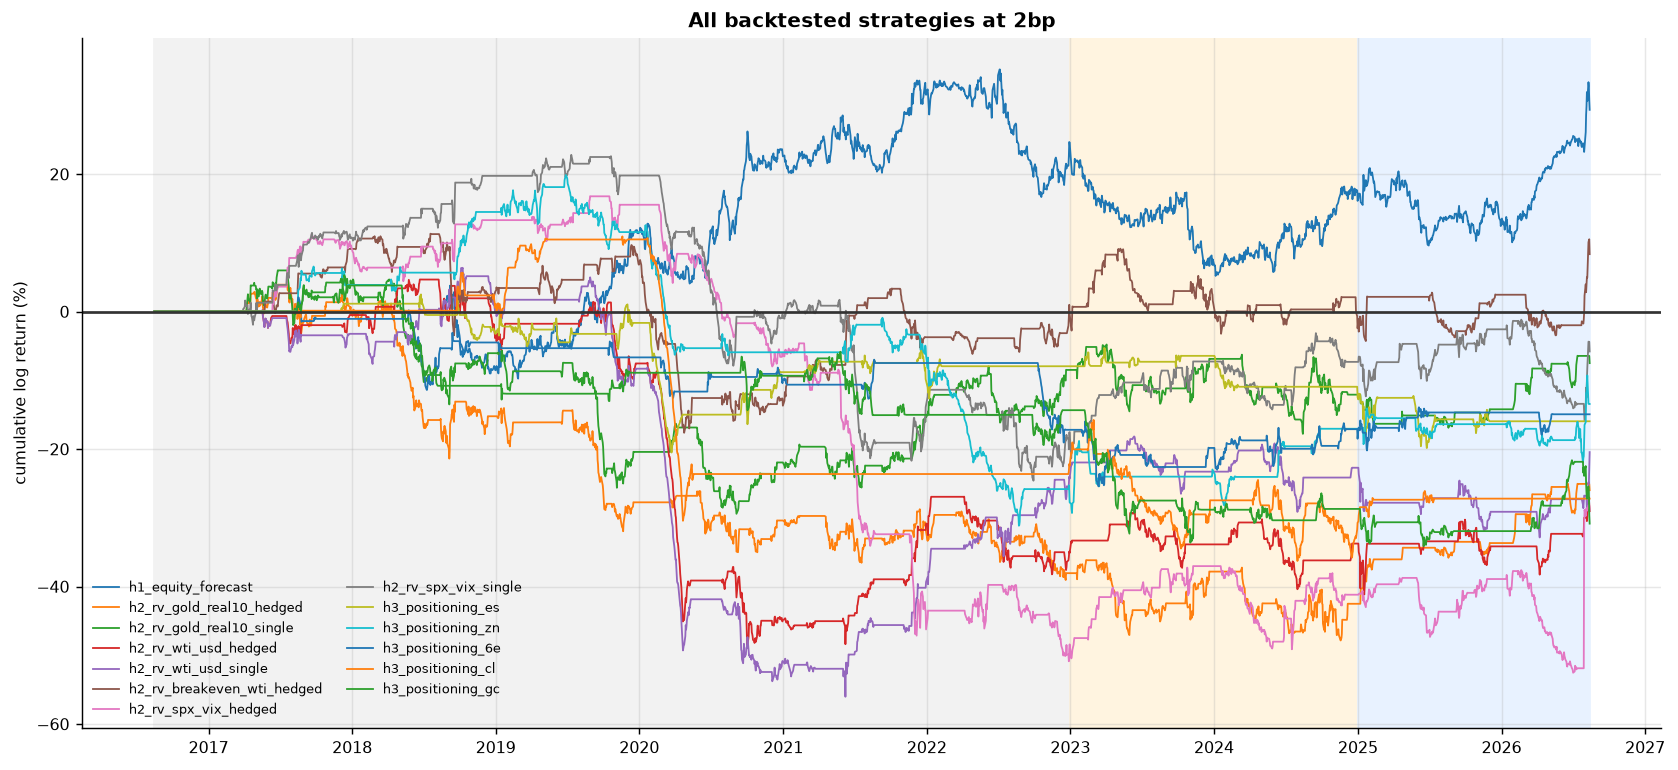

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))
for name, result in results["backtest_results"].items():
    ax.plot(result.returns.index, result.returns.cumsum() * 100, linewidth=1.0, label=name)
colours = {"train": "#f2f2f2", "validation": "#fff4e0", "test": "#e8f2ff"}
for label, (lo, hi) in config.SPLITS.items():
    ax.axvspan(lo, hi, color=colours[label], zorder=0)
ax.axhline(0, color="#333333"); ax.grid(alpha=0.3)
ax.set_ylabel("cumulative log return (%)")
ax.set_title(f"All backtested strategies at {config.HEADLINE_COST_BPS:.0f}bp")
ax.legend(fontsize=7, ncol=2, loc="lower left")
plt.tight_layout(); plt.show()

## Transaction cost sensitivity

The question is not what costs are, but whether the conclusion survives them.

In [9]:
summary = results["backtest_summary"]
summary[summary["split"] == "test"].pivot_table(index="signal", columns="cost_bps", values="sharpe")

cost_bps,0.0000,1.0000,2.0000,5.0000
signal,,,,
h1_equity_forecast,0.9476,0.8943,0.8407,0.6796
h2_rv_breakeven_wti_hedged,0.8573,0.8284,0.7995,0.7126
h2_rv_gold_real10_hedged,1.8271,1.8115,1.7959,1.7489
h2_rv_gold_real10_single,0.5526,0.5344,0.5162,0.4617
h2_rv_spx_vix_hedged,0.4534,0.4493,0.4451,0.4327
h2_rv_spx_vix_single,0.1178,0.1091,0.1003,0.0741
h2_rv_wti_usd_hedged,0.3249,0.3225,0.3200,0.3127
h2_rv_wti_usd_single,0.1884,0.1851,0.1818,0.1719
h3_positioning_6e,0.4796,0.4601,0.4406,0.3821


Turnover here is low, so the grid does not overturn any conclusion. That is a property of a multi-week average holding period, not a claim that costs do not matter: a signal trading ten times more often would be destroyed by the same grid.

## Regime attribution

In [10]:
regime = results["regime_performance"]
primary = regime[regime["signal"] == results["primary_strategy"]]
primary[["dimension", "regime", "days", "annual_return", "sharpe", "max_drawdown", "hit_rate", "trades"]]

,dimension,regime,days,annual_return,sharpe,max_drawdown,hit_rate,trades
11,volatility,low VIX (<11.4),781,0.0043,0.0699,-0.1344,0.4685,27
12,volatility,mid VIX (11.4-18.2),769,-0.0127,-0.1377,-0.2252,0.4846,35
13,volatility,high VIX (>18.2),836,-0.0706,-0.7465,-0.2983,0.4706,32
14,curve,0-100bp,1850,-0.0352,-0.4206,-0.5166,0.4764,75
15,curve,>100bp,178,0.0068,0.0900,-0.0613,0.4811,7
16,curve,inverted,358,-0.0042,-0.0457,-0.1379,0.4932,12
17,real_yield,middle 50% (-0.03-1.48%),1130,-0.0777,-0.8557,-0.5179,0.4708,42
18,real_yield,bottom quartile (<-0.03%),628,-0.0234,-0.2833,-0.1247,0.4733,25
19,real_yield,top quartile (>1.48%),628,0.0590,0.8022,-0.0956,0.5000,27
20,usd,USD strengthening,1098,-0.0210,-0.2517,-0.2131,0.4734,46


Regime labels are cut on the full sample, so this is ex-post attribution, not a tradable filter. A regime-conditioned strategy using full-sample breakpoints is a lookahead bug with a respectable name.

## Multiple testing

In [11]:
holm = results["holm"]
print(f"family size: {len(holm)}; significant after Holm-Bonferroni: {int(holm['significant_5pct'].sum())}")
holm.head(12)

family size: 22; significant after Holm-Bonferroni: 3


,test,p_value,p_holm,significant_5pct,family_size
0,H1 ret_1d_vix,0.0000,0.0000,True,22
1,H1 dy_1d_real10,0.0000,0.0000,True,22
2,H1 dy_1d_slope,0.0000,0.0000,True,22
3,H1 dy_1d_breakeven10,0.0075,0.1431,False,22
4,H2/H3 h2_rv_gold_real10_hedged OOS Sharpe,0.0230,0.4135,False,22
5,H2/H3 h1_equity_forecast OOS Sharpe,0.2871,1.0000,False,22
6,H2/H3 h2_rv_breakeven_wti_hedged OOS Sharpe,0.3114,1.0000,False,22
7,H2/H3 h3_positioning_cl OOS Sharpe,0.3168,1.0000,False,22
8,H3 cl top-vs-bottom decile 21d,0.3775,1.0000,False,22
9,H2/H3 h2_rv_gold_real10_single OOS Sharpe,0.5133,1.0000,False,22


## Key figures

Generated from the tables above, not typed in.

In [12]:
for row in results["key_figures"].itertuples():
    print(f"{row.figure}\n    {row.value}\n")

1. Datasets
    5: FRED daily market series; ALFRED vintage macroeconomic series; CFTC Traders in Financial Futures (COT); CFTC Disaggregated Futures (COT); Cboe VIX history

2. Instruments and series
    13 daily market series, 5 vintage macro series, 5 CFTC positioning markets = 23 total; 164 engineered features

3. Daily observations
    2,512 trading days; 32,656 daily series-observations; 522 weekly COT reports; 1,833 macro vintage rows

4. Start and end date
    2016-08-15 to 2026-08-13 (frozen). Train to 2022-12-31, validation to 2024-12-31, test from 2025-01-01

5. Candidate signals tested
    14 declared in signals.SIGNAL_REGISTRY, of which 13 were backtested; 3 regression specifications; 5 relative-value pairs; 5 positioning markets

6. Actual trades
    1,596 across all backtested signals, full sample, at 2bp

7. Best out-of-sample Sharpe
    1.80 (h2_rv_gold_real10_hedged, 404 days, 21 trades, 2bp costs). This figure should not be read in isolation: 0 of 13 strategies were 